<a href="https://colab.research.google.com/github/selvimaharanip/bi-analyst-portfolio/blob/main/credit-utilization-portfolio-analysis/credit_utilization_eda_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Preparation & Exploratory Data Analysis

First, import the required libraries and load the dataset, then review the basic dataset information.

In [3]:
import pandas as pd
from scipy import stats
import numpy as np
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

In [4]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Bootcamp/Sample data/transactions.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641914 entries, 0 to 641913
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   accountNumber             641914 non-null  int64  
 1   customerId                641914 non-null  int64  
 2   creditLimit               641914 non-null  int64  
 3   availableMoney            641914 non-null  float64
 4   transactionDateTime       641914 non-null  object 
 5   transactionAmount         641914 non-null  float64
 6   merchantName              641914 non-null  object 
 7   acqCountry                638001 non-null  object 
 8   merchantCountryCode       641290 non-null  object 
 9   posEntryMode              638569 non-null  float64
 10  posConditionCode          641627 non-null  float64
 11  merchantCategoryCode      641914 non-null  object 
 12  currentExpDate            641914 non-null  object 
 13  accountOpenDate           641914 non-null  o

In [6]:
df.dtypes

,0
accountNumber,int64
customerId,int64
creditLimit,int64
availableMoney,float64
transactionDateTime,object
transactionAmount,float64
merchantName,object
acqCountry,object
merchantCountryCode,object
posEntryMode,float64


In [7]:
df.head(10)

,accountNumber,customerId,creditLimit,availableMoney,transactionDateTime,transactionAmount,merchantName,acqCountry,merchantCountryCode,posEntryMode,...,accountOpenDate,dateOfLastAddressChange,cardCVV,enteredCVV,cardLast4Digits,transactionType,isFraud,currentBalance,cardPresent,expirationDateKeyInMatch
0,733493772,733493772,5000,5000.00,2016-01-08T19:04:50,111.33,Lyft,US,US,5.0,...,3/8/2014,3/8/2014,492,492,9184,PURCHASE,True,0.00,False,False
1,733493772,733493772,5000,4888.67,2016-01-09T22:32:39,24.75,Uber,US,US,9.0,...,3/8/2014,3/8/2014,492,492,9184,PURCHASE,False,111.33,False,False
2,733493772,733493772,5000,4863.92,2016-01-11T13:36:55,187.40,Lyft,US,US,5.0,...,3/8/2014,3/8/2014,492,492,9184,PURCHASE,False,136.08,False,False
3,733493772,733493772,5000,4676.52,2016-01-11T22:47:46,227.34,Lyft,US,US,2.0,...,3/8/2014,3/8/2014,492,492,9184,PURCHASE,True,323.48,False,False
4,733493772,733493772,5000,4449.18,2016-01-16T01:41:11,0.00,Lyft,US,US,2.0,...,3/8/2014,3/8/2014,492,492,9184,ADDRESS_VERIFICATION,False,550.82,False,False
5,733493772,733493772,5000,4449.18,2016-01-16T21:35:27,9.80,Fresh eCards,US,US,5.0,...,3/8/2014,3/8/2014,492,492,9184,PURCHASE,False,550.82,False,False
6,733493772,733493772,5000,4439.38,2016-01-24T07:54:01,247.99,Uber,NaN,US,5.0,...,3/8/2014,3/8/2014,492,492,9184,PURCHASE,False,560.62,False,False
7,733493772,733493772,5000,4191.39,2016-01-26T05:28:24,0.00,Universe Massage #95463,US,US,5.0,...,3/8/2014,3/8/2014,492,492,9184,ADDRESS_VERIFICATION,False,808.61,False,False
8,733493772,733493772,5000,4191.39,2016-01-26T12:18:14,11.54,Universe Massage #70014,US,US,5.0,...,3/8/2014,3/8/2014,492,492,9184,PURCHASE,False,808.61,True,False
9,733493772,733493772,5000,4179.85,2016-01-26T12:19:15,11.54,Universe Massage #70014,US,US,5.0,...,3/8/2014,3/8/2014,492,492,9184,REVERSAL,False,820.15,True,False


In [8]:
df.describe()

,accountNumber,customerId,creditLimit,availableMoney,transactionAmount,posEntryMode,posConditionCode,cardCVV,enteredCVV,cardLast4Digits,currentBalance
count,6.419140e+05,6.419140e+05,641914.000000,641914.000000,641914.000000,638569.000000,641627.000000,641914.000000,641914.000000,641914.000000,641914.000000
mean,5.547701e+08,5.547701e+08,10697.210608,6652.828573,135.162497,9.136460,3.238367,557.199927,556.775160,4886.184043,4044.382035
std,2.546884e+08,2.546884e+08,11460.359133,9227.132275,147.053302,16.961185,9.680862,257.326204,257.402639,2859.053679,5945.510224
min,1.005471e+08,1.005471e+08,250.000000,-1244.930000,0.000000,2.000000,1.000000,100.000000,1.000000,0.000000,0.000000
25%,3.223192e+08,3.223192e+08,5000.000000,1114.970000,32.320000,2.000000,1.000000,334.000000,333.000000,2364.000000,502.442500
50%,5.438879e+08,5.438879e+08,7500.000000,3578.165000,85.800000,5.000000,1.000000,581.000000,580.000000,4873.000000,2151.860000
75%,7.862277e+08,7.862277e+08,15000.000000,8169.185000,189.030000,9.000000,1.000000,762.000000,761.000000,7267.000000,5005.890000
max,9.999853e+08,9.999853e+08,50000.000000,50000.000000,1825.250000,90.000000,99.000000,998.000000,998.000000,9998.000000,47496.500000


In [9]:
df.describe(include=object)

,transactionDateTime,merchantName,acqCountry,merchantCountryCode,merchantCategoryCode,currentExpDate,accountOpenDate,dateOfLastAddressChange,transactionType
count,641914,641914,638001,641290,641914,641914,641914,641914,641325
unique,635472,2493,4,4,19,165,1826,2186,3
top,2016-01-19T04:26:56,Lyft,US,US,online_retail,1/5/2026,11/12/2015,20/7/2016,PURCHASE
freq,3,25311,632303,635577,161469,4209,10137,3948,608685


# Exploratory Data Analysis (EDA)

## Univariate Exploration

### String Data Type Exploration

**1. transactionType**

The transactionType variable contains the types of transactions performed.
This exploration aims to examine the distribution of transaction counts by category.

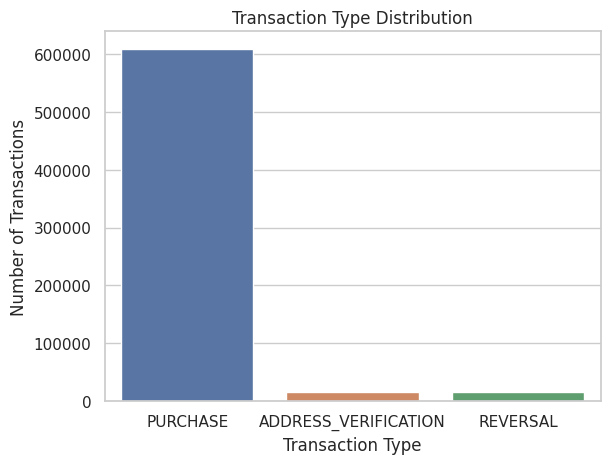

In [10]:
transaction_counts = df['transactionType'].value_counts().reset_index()
transaction_counts.columns = ['transactionType', 'count']

sns.barplot(data=transaction_counts, x="transactionType", y="count", hue="transactionType")
plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.show()

From the chart, we can conclude that the most frequent transaction type falls under the purchase category.

**2. transactionDateTime**

The transactionDateTime variable contains timestamp data for each transaction.
This exploration aims to examine the distribution of transactions across different hours.

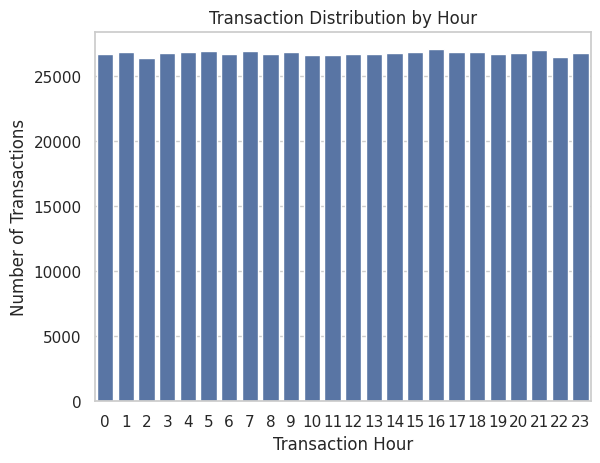

In [11]:
# Convert transactionDateTime from string to datetime format
df['transactionDateTime'] = pd.to_datetime(df['transactionDateTime'])

df['hour'] = df['transactionDateTime'].dt.hour

sns.countplot(data=df, x='hour')
plt.title("Transaction Distribution by Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Number of Transactions")
plt.show()

From the chart, transaction distribution appears relatively evenly spread across hours.

**3. cardPresent**

The cardPresent variable indicates whether a physical card was used during the transaction.
This analysis compares physical vs non-physical card usage.

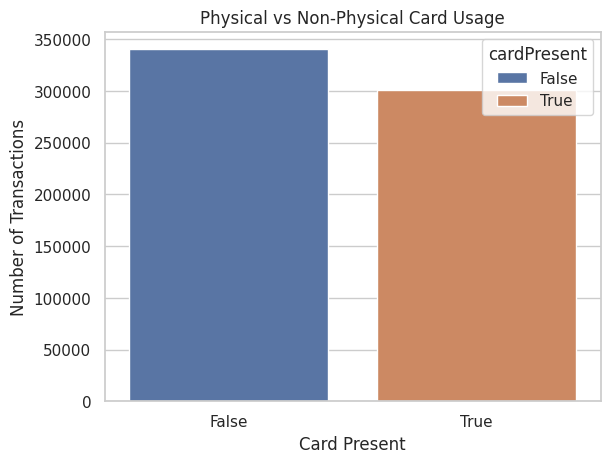

In [12]:
cardpresent_counts = df['cardPresent'].value_counts().reset_index()
cardpresent_counts.columns = ['cardPresent', 'count']

sns.barplot(data=cardpresent_counts, x="cardPresent", y="count", hue="cardPresent")
plt.title("Physical vs Non-Physical Card Usage")
plt.xlabel("Card Present")
plt.ylabel("Number of Transactions")
plt.show()

The chart indicates that more transactions are conducted using non-physical cards.

**4. merchantName**

The merchantName variable contains merchant names where transactions occurred.

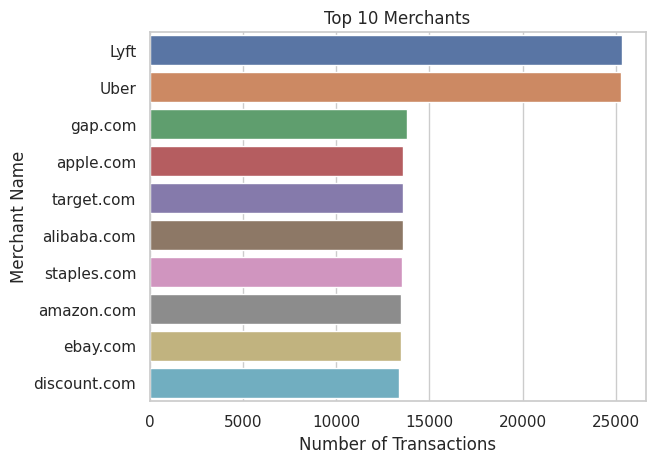

In [13]:
merchant_counts = df['merchantName'].value_counts().head(10).reset_index()
merchant_counts.columns = ['merchantName', 'count']

sns.barplot(data=merchant_counts, x="count", y="merchantName", hue="merchantName")
plt.title("Top 10 Merchants")
plt.xlabel("Number of Transactions")
plt.ylabel("Merchant Name")
plt.show()

Among the top 10 merchants, Lyft and Uber appear most frequently.

**5. merchantCategoryCode**

This variable represents the merchant’s business category.

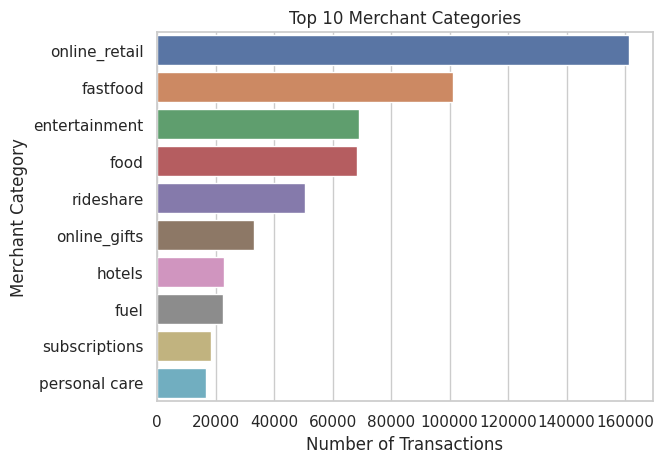

In [14]:
category_counts = df['merchantCategoryCode'].value_counts().head(10).reset_index()
category_counts.columns = ['merchantCategoryCode', 'count']

sns.barplot(data=category_counts, x="count", y="merchantCategoryCode", hue="merchantCategoryCode")
plt.title("Top 10 Merchant Categories")
plt.xlabel("Number of Transactions")
plt.ylabel("Merchant Category")
plt.show()

The top categories include online retail and fast food.

**6. merchantCountryCode**

Represents the country where the merchant is located.

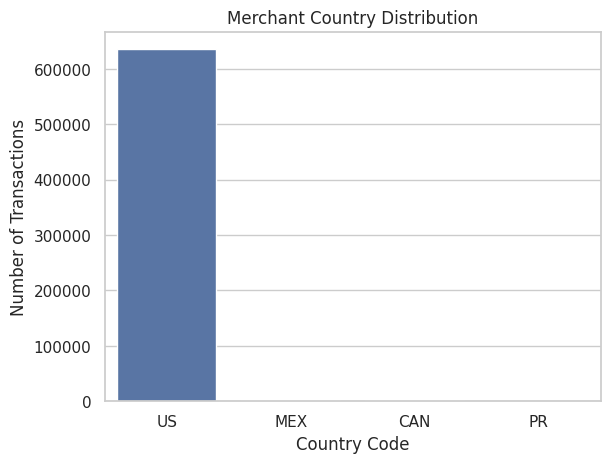

In [15]:
country_counts = df['merchantCountryCode'].value_counts().reset_index()
country_counts.columns = ['merchantCountryCode', 'count']

sns.barplot(data=country_counts, x="merchantCountryCode", y="count", hue="merchantCountryCode")
plt.title("Merchant Country Distribution")
plt.xlabel("Country Code")
plt.ylabel("Number of Transactions")
plt.show()

Most transactions originate from merchants located in the US.

**7. acqCountry**

Represents the country of the acquiring bank.

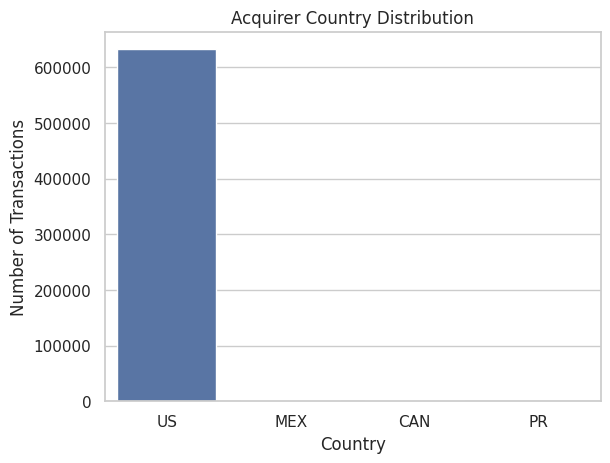

In [16]:
acq_counts = df['acqCountry'].value_counts().reset_index()
acq_counts.columns = ['acqCountry', 'count']

sns.barplot(data=acq_counts, x="acqCountry", y="count", hue="acqCountry")
plt.title("Acquirer Country Distribution")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.show()

In [17]:
df.acqCountry.describe()

,acqCountry
count,638001
unique,4
top,US
freq,632303


The dataset is heavily dominated by transactions acquired in the US (632,303 transactions).

**8. isFraud**

Indicates whether a transaction is fraudulent.

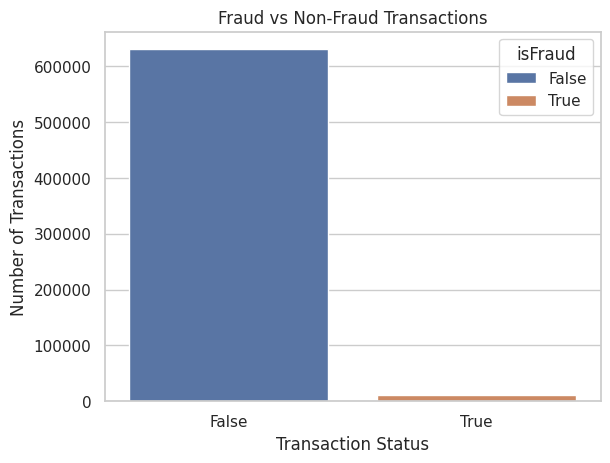

In [18]:
fraud_count = df.isFraud.value_counts().reset_index()
fraud_count.columns = ["isFraud", "count"]

sns.barplot(data=fraud_count, x="isFraud", y="count", hue="isFraud")
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Transaction Status")
plt.ylabel("Number of Transactions")
plt.show()

Fraud transactions are significantly fewer compared to non-fraud transactions.

### Numeric Data Exploration

**1. creditLimit**

Text(0, 0.5, 'Density')

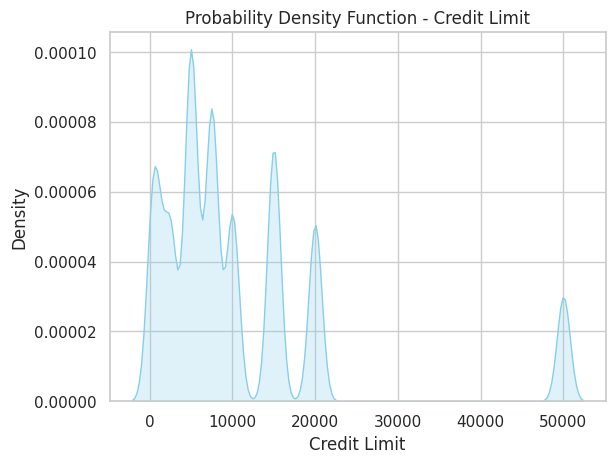

In [19]:
sns.kdeplot(df.creditLimit, fill=True, color="skyblue")
plt.title("Probability Density Function - Credit Limit")
plt.xlabel("Credit Limit")
plt.ylabel("Density")

In [20]:
print("Skewness: ", df.creditLimit.skew())

Skewness:  2.294548813378859


Most customers have credit limits between 0–30,000.
The skewness of 2.29 indicates a strong right-skewed distribution.

**2. availableMoney**

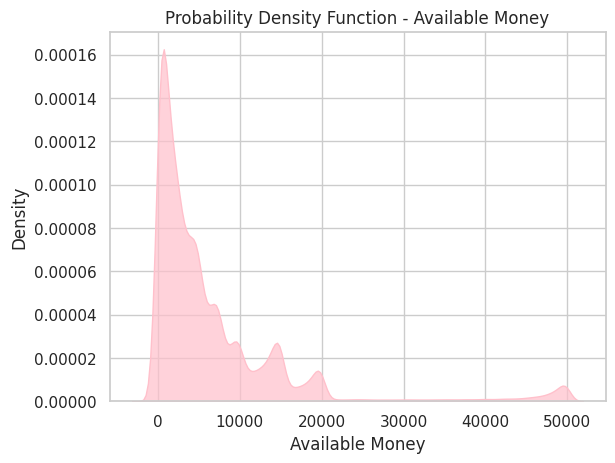

In [21]:
sns.kdeplot(df.availableMoney, fill=True, color="pink", alpha=0.7)
plt.title("Probability Density Function - Available Money")
plt.xlabel("Available Money")
plt.ylabel("Density")
plt.show()

In [22]:
print("Skewness: ", df.availableMoney.skew())

Skewness:  2.888834824892849


Skewness of 2.8888 shows a highly right-skewed distribution.

**3. transactionAmount**

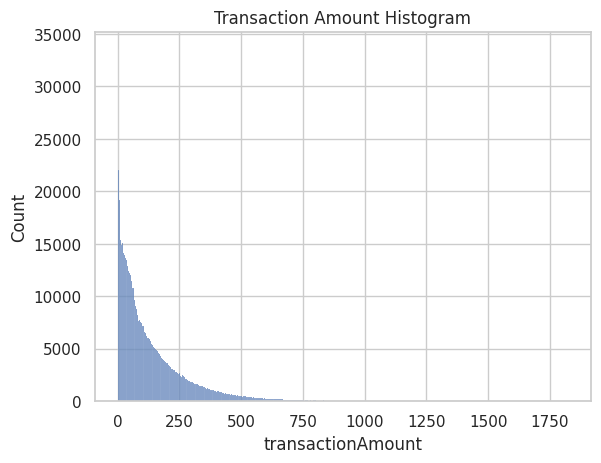

In [23]:
sns.histplot(df.transactionAmount)
plt.title("Transaction Amount Histogram")
plt.show()

In [24]:
print("Skewness: ", df.transactionAmount.skew())

Skewness:  2.09571515354587


Skewness of 2.0957 indicates most transactions are relatively small (0–750).

**4. currentBalance**

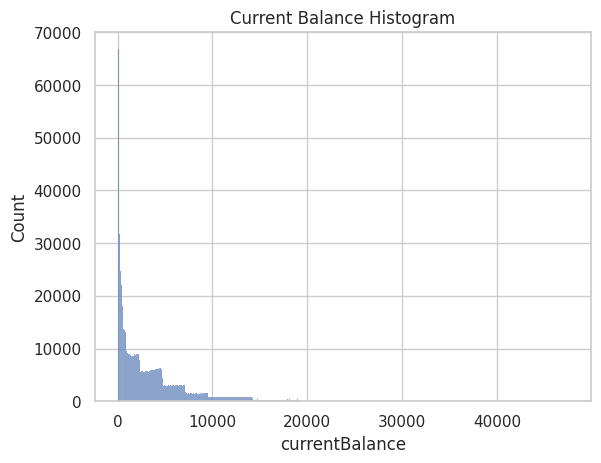

In [25]:
sns.histplot(df.currentBalance)
plt.title("Current Balance Histogram")
plt.show()

In [26]:
print("Skewness: ", df.currentBalance.skew())

Skewness:  3.600021657637472


Skewness of 3.6000 shows a highly right-skewed balance distribution.

## Bivariate Exploration

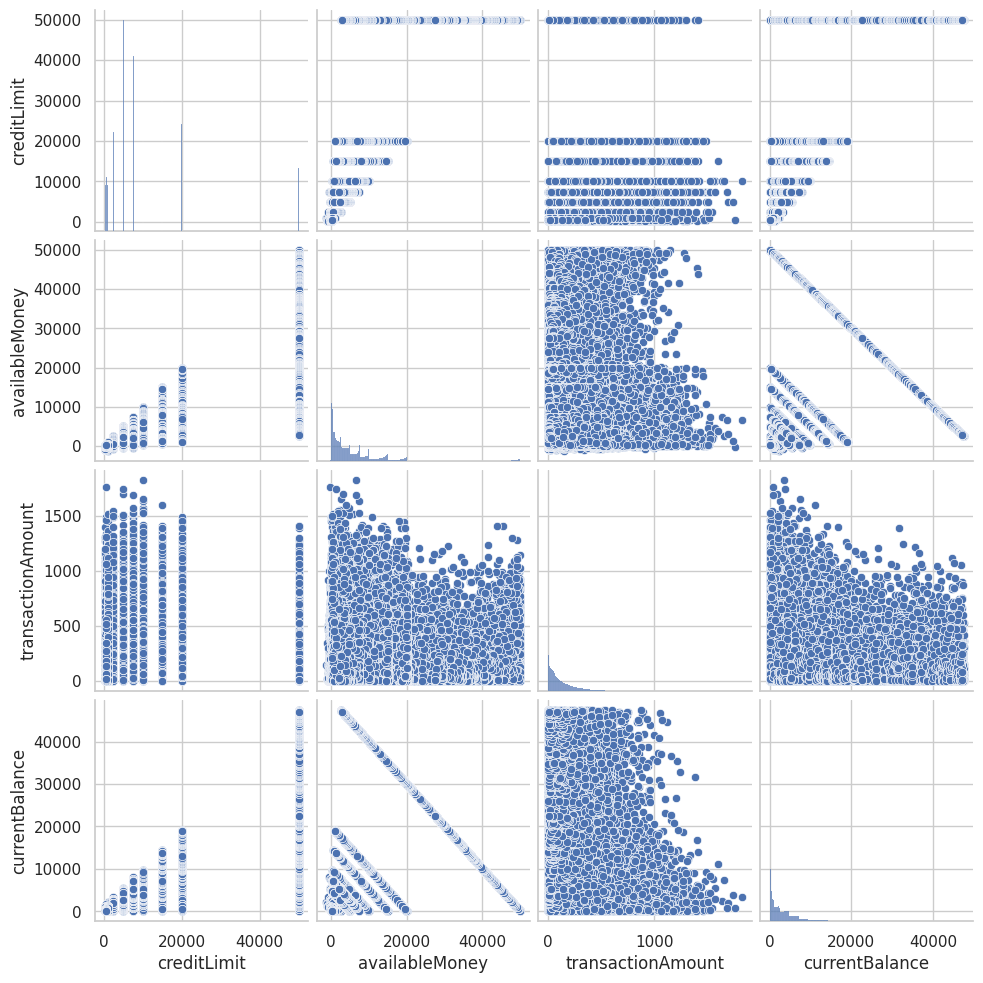

In [27]:
sns.pairplot(df[["creditLimit", "availableMoney", "transactionAmount", "currentBalance"]])
plt.show()

Key insights:

- creditLimit and currentBalance show a positive relationship.
- availableMoney and currentBalance show a mechanical inverse relationship.
- transactionAmount shows weak correlation with other variables.
 Increasing credit limits does not automatically increase transaction size.

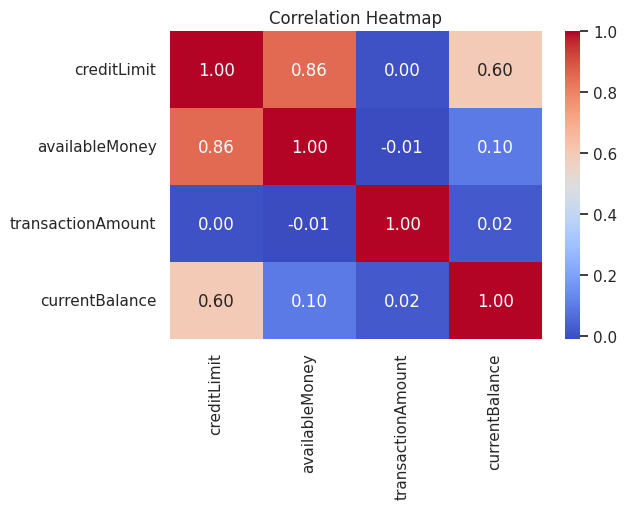

In [28]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df[["creditLimit", "availableMoney", "transactionAmount", "currentBalance"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

The strongest correlation is between creditLimit and availableMoney (0.86), reflecting structural system behavior rather than customer behavior.

# Data Cleaning

Steps performed:
1. Handling Missing Values
2. Handling Outliers
3. Removing Duplicates
4. Formatting Data

## Handling Missing Values

In [29]:
# Checking missing values per records
df.isnull()

,accountNumber,customerId,creditLimit,availableMoney,transactionDateTime,transactionAmount,merchantName,acqCountry,merchantCountryCode,posEntryMode,...,dateOfLastAddressChange,cardCVV,enteredCVV,cardLast4Digits,transactionType,isFraud,currentBalance,cardPresent,expirationDateKeyInMatch,hour
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641909,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
641910,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
641911,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
641912,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [30]:
# Looking at columns that have missing values
df[df.isnull().any(axis = 1)]

,accountNumber,customerId,creditLimit,availableMoney,transactionDateTime,transactionAmount,merchantName,acqCountry,merchantCountryCode,posEntryMode,...,dateOfLastAddressChange,cardCVV,enteredCVV,cardLast4Digits,transactionType,isFraud,currentBalance,cardPresent,expirationDateKeyInMatch,hour
6,733493772,733493772,5000,4439.38,2016-01-24 07:54:01,247.99,Uber,NaN,US,5.0,...,3/8/2014,492,492,9184,PURCHASE,False,560.62,False,False,7
32,733493772,733493772,5000,2457.68,2016-03-26 17:23:05,341.98,Uber,US,US,NaN,...,3/8/2014,492,492,9184,PURCHASE,False,2542.32,False,False,17
153,733493772,733493772,5000,559.50,2016-11-17 20:33:50,266.66,Uber,US,US,NaN,...,26/6/2016,492,492,9184,PURCHASE,False,4440.50,False,False,20
201,578754168,578754168,5000,4676.42,2016-08-26 13:09:55,93.44,Boston Cafe #592935,NaN,NaN,9.0,...,21/10/2015,413,413,5279,PURCHASE,False,323.58,True,False,13
563,223895414,223895414,50000,50000.00,2016-01-03 17:33:49,144.04,Franks Restaurant,NaN,US,9.0,...,31/5/2014,671,671,2849,PURCHASE,False,0.00,True,False,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641330,298100844,298100844,5000,1665.99,2016-06-13 02:51:23,94.87,Ray's Fries #745083,US,US,NaN,...,5/1/2016,204,204,6087,PURCHASE,False,3334.01,True,False,2
641511,298100844,298100844,5000,678.23,2016-10-25 05:30:34,189.98,Downtown Pub,US,US,NaN,...,5/1/2016,881,881,5160,PURCHASE,False,4321.77,True,False,5
641626,877651598,877651598,7500,5854.66,2016-11-21 02:19:09,52.51,Lyft,NaN,NaN,5.0,...,7/1/2012,547,547,3593,PURCHASE,False,1645.34,False,False,2
641780,455115932,455115932,50000,36162.74,2016-08-20 08:20:20,2.12,Fresh Online Services,US,US,9.0,...,2/2/2011,148,148,2521,NaN,False,13837.26,False,False,8


In [31]:
# Checking the number of missing data in every column
df.isnull().sum()

,0
accountNumber,0
customerId,0
creditLimit,0
availableMoney,0
transactionDateTime,0
transactionAmount,0
merchantName,0
acqCountry,3913
merchantCountryCode,624
posEntryMode,3345


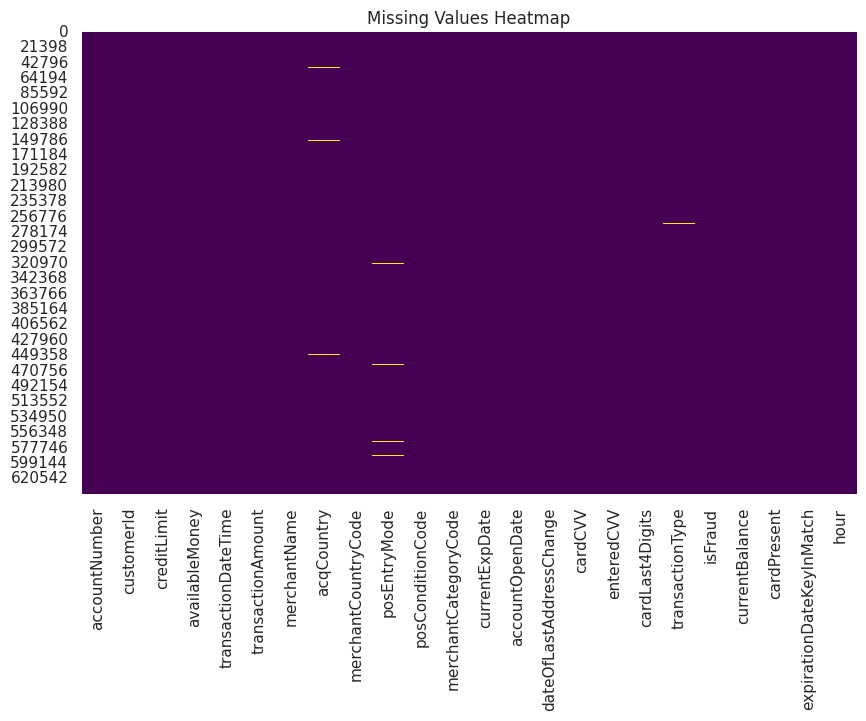

In [32]:
# Use heatmap to visualize missing values
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

**Imputing missing values**

Missing values are minimal (<1% per column), so imputation is preferred over dropping rows. The data shows:

* acqCountry: 0.61%
* merchantCountryCode: 0.09%
* posEntryMode: 0.52%
* posConditionCode: 0.04%
* transactionType: 0.09%

**acqCountry**

In [33]:
df["acqCountry"] = df["acqCountry"].fillna("Unknown")
print(df["acqCountry"])

0         US
1         US
2         US
3         US
4         US
          ..
641909    US
641910    US
641911    US
641912    US
641913    US
Name: acqCountry, Length: 641914, dtype: object


**merchantCountryCode**

In [34]:
df["merchantCountryCode"] = df["merchantCountryCode"].fillna("Unknown")
print(df["merchantCountryCode"])

0         US
1         US
2         US
3         US
4         US
          ..
641909    US
641910    US
641911    US
641912    US
641913    US
Name: merchantCountryCode, Length: 641914, dtype: object


**transactionType**

In [35]:
df["transactionType"] = df["transactionType"].fillna("Unknown")
print(df["transactionType"])

0                     PURCHASE
1                     PURCHASE
2                     PURCHASE
3                     PURCHASE
4         ADDRESS_VERIFICATION
                  ...         
641909                PURCHASE
641910                PURCHASE
641911                PURCHASE
641912                PURCHASE
641913                PURCHASE
Name: transactionType, Length: 641914, dtype: object


**posEntryMode**

In [36]:
df["posEntryMode"] = df["posEntryMode"].fillna(df["posEntryMode"].mode()[0])
print(df["posEntryMode"])

0         5.0
1         9.0
2         5.0
3         2.0
4         2.0
         ... 
641909    5.0
641910    9.0
641911    2.0
641912    9.0
641913    9.0
Name: posEntryMode, Length: 641914, dtype: float64


**posConditionCode**

In [37]:
df["posConditionCode"] = df["posConditionCode"].fillna(df["posConditionCode"].mode()[0])
print(df["posConditionCode"])

0         1.0
1         1.0
2         1.0
3         1.0
4         1.0
         ... 
641909    8.0
641910    1.0
641911    1.0
641912    8.0
641913    1.0
Name: posConditionCode, Length: 641914, dtype: float64


In [38]:
print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
accountNumber               0
customerId                  0
creditLimit                 0
availableMoney              0
transactionDateTime         0
transactionAmount           0
merchantName                0
acqCountry                  0
merchantCountryCode         0
posEntryMode                0
posConditionCode            0
merchantCategoryCode        0
currentExpDate              0
accountOpenDate             0
dateOfLastAddressChange     0
cardCVV                     0
enteredCVV                  0
cardLast4Digits             0
transactionType             0
isFraud                     0
currentBalance              0
cardPresent                 0
expirationDateKeyInMatch    0
hour                        0
dtype: int64


In [39]:
df[df.isnull().any(axis = 1)]

,accountNumber,customerId,creditLimit,availableMoney,transactionDateTime,transactionAmount,merchantName,acqCountry,merchantCountryCode,posEntryMode,...,dateOfLastAddressChange,cardCVV,enteredCVV,cardLast4Digits,transactionType,isFraud,currentBalance,cardPresent,expirationDateKeyInMatch,hour


All missing values have been successfully handled.

## Handling Outliers

**creditLimit**

<Axes: xlabel='creditLimit'>

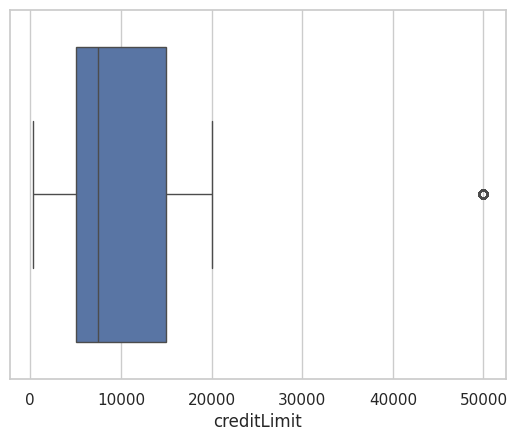

In [40]:
import seaborn as sns

sns.boxplot(x=df["creditLimit"])

**availableMoney**

<Axes: xlabel='availableMoney'>

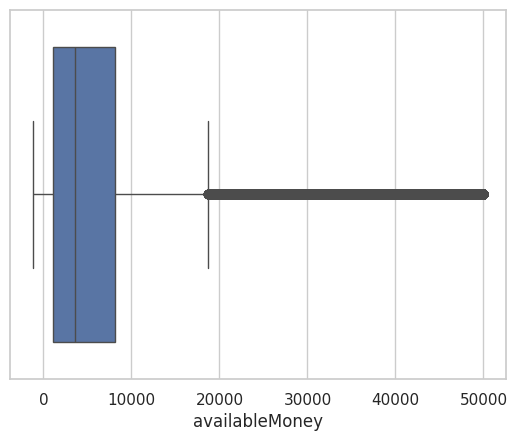

In [41]:
sns.boxplot(x=df["availableMoney"])

**transactionAmount**

<Axes: xlabel='transactionAmount'>

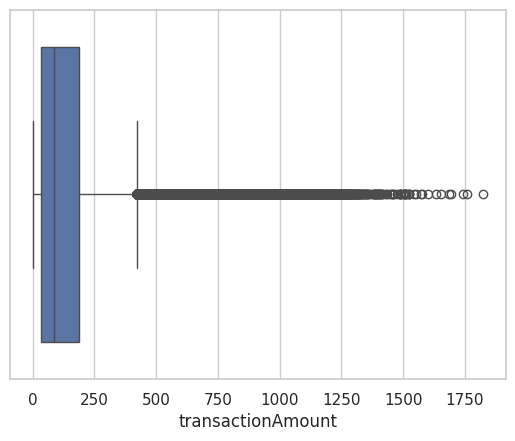

In [42]:
sns.boxplot(x=df["transactionAmount"])

**currentBalance**

<Axes: xlabel='currentBalance'>

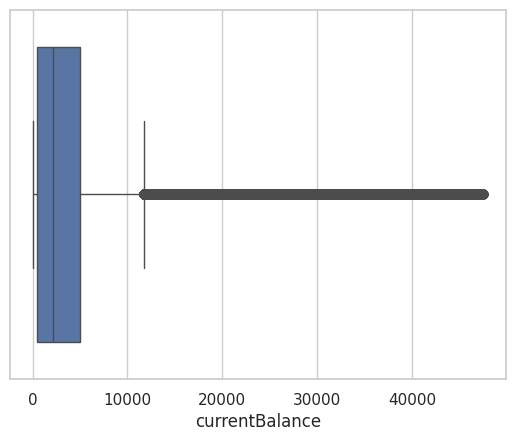

In [43]:
sns.boxplot(x=df["currentBalance"])

### Calculating IQR Value

In [44]:
df.describe()

,accountNumber,customerId,creditLimit,availableMoney,transactionDateTime,transactionAmount,posEntryMode,posConditionCode,cardCVV,enteredCVV,cardLast4Digits,currentBalance,hour
count,6.419140e+05,6.419140e+05,641914.000000,641914.000000,641914,641914.000000,641914.000000,641914.000000,641914.000000,641914.000000,641914.000000,641914.000000,641914.000000
mean,5.547701e+08,5.547701e+08,10697.210608,6652.828573,2016-07-06 16:07:40.142365952,135.162497,9.114905,3.237367,557.199927,556.775160,4886.184043,4044.382035,11.504490
min,1.005471e+08,1.005471e+08,250.000000,-1244.930000,2016-01-01 00:00:37,0.000000,2.000000,1.000000,100.000000,1.000000,0.000000,0.000000,0.000000
25%,3.223192e+08,3.223192e+08,5000.000000,1114.970000,2016-04-07 09:33:49.750000128,32.320000,2.000000,1.000000,334.000000,333.000000,2364.000000,502.442500,6.000000
50%,5.438879e+08,5.438879e+08,7500.000000,3578.165000,2016-07-08 23:46:03.500000,85.800000,5.000000,1.000000,581.000000,580.000000,4873.000000,2151.860000,12.000000
75%,7.862277e+08,7.862277e+08,15000.000000,8169.185000,2016-10-06 09:46:48.249999872,189.030000,9.000000,1.000000,762.000000,761.000000,7267.000000,5005.890000,17.000000
max,9.999853e+08,9.999853e+08,50000.000000,50000.000000,2016-12-30 23:59:27,1825.250000,90.000000,99.000000,998.000000,998.000000,9998.000000,47496.500000,23.000000
std,2.546884e+08,2.546884e+08,11460.359133,9227.132275,NaN,147.053302,16.919556,9.678814,257.326204,257.402639,2859.053679,5945.510224,6.919566


Nilai IQR pada creditLimit

In [45]:
q1_credit = df['creditLimit'].quantile(0.25)
q3_credit = df['creditLimit'].quantile(0.75)
iqr_credit = q3_credit - q1_credit

lower_bound_credit = q1_credit - (1.5 * iqr_credit)
upper_bound_credit = q3_credit + (1.5 * iqr_credit)

print('lower bound creditLimit:', lower_bound_credit)
print('upper bound creditLimit:', upper_bound_credit)

lower bound creditLimit: -10000.0
upper bound creditLimit: 30000.0


IQR value on availableMoney

In [46]:
q1_money = df['availableMoney'].quantile(0.25)
q3_money = df['availableMoney'].quantile(0.75)
iqr_money = q3_money - q1_money

lower_bound_money = q1_money - (1.5 * iqr_money)
upper_bound_money = q3_money + (1.5 * iqr_money)

print('lower bound availableMoney:', lower_bound_money)
print('upper bound availableMoney:', upper_bound_money)

lower bound availableMoney: -9466.352499999999
upper bound availableMoney: 18750.5075


IQR value on transactionAmount

In [47]:
q1_transaction = df['transactionAmount'].quantile(0.25)
q3_transaction = df['transactionAmount'].quantile(0.75)
iqr_transaction = q3_transaction - q1_transaction

lower_bound_transaction = q1_transaction - (1.5 * iqr_transaction)
upper_bound_transaction = q3_transaction + (1.5 * iqr_transaction)

print('lower bound transactionAmount:', lower_bound_transaction)
print('upper bound transactionAmount:', upper_bound_transaction)

lower bound transactionAmount: -202.745
upper bound transactionAmount: 424.095


IQR value on currentBalance

In [48]:
q1_balance = df['currentBalance'].quantile(0.25)
q3_balance = df['currentBalance'].quantile(0.75)
iqr_balance = q3_balance - q1_balance

lower_bound_balance = q1_balance - (1.5 * iqr_balance)
upper_bound_balance = q3_balance + (1.5 * iqr_balance)

print('lower bound currentBalance:', lower_bound_balance)
print('upper bound currentBalance:', upper_bound_balance)

lower bound currentBalance: -6252.728749999999
upper bound currentBalance: 11761.061249999999


Outliers are retained because they represent real high-value customers rather than data errors.

## Handling Duplicate Values

In [49]:
# Checking duplicate per rows
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
641909,False
641910,False
641911,False
641912,False


In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
df[df.duplicated()]

,accountNumber,customerId,creditLimit,availableMoney,transactionDateTime,transactionAmount,merchantName,acqCountry,merchantCountryCode,posEntryMode,...,dateOfLastAddressChange,cardCVV,enteredCVV,cardLast4Digits,transactionType,isFraud,currentBalance,cardPresent,expirationDateKeyInMatch,hour


No duplicate records found.

## Data Type Formatting

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641914 entries, 0 to 641913
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   accountNumber             641914 non-null  int64         
 1   customerId                641914 non-null  int64         
 2   creditLimit               641914 non-null  int64         
 3   availableMoney            641914 non-null  float64       
 4   transactionDateTime       641914 non-null  datetime64[ns]
 5   transactionAmount         641914 non-null  float64       
 6   merchantName              641914 non-null  object        
 7   acqCountry                641914 non-null  object        
 8   merchantCountryCode       641914 non-null  object        
 9   posEntryMode              641914 non-null  float64       
 10  posConditionCode          641914 non-null  float64       
 11  merchantCategoryCode      641914 non-null  object        
 12  cu

Based on the information above, several variables have data types that are not fully appropriate and therefore need to be reformatted to facilitate further analysis.

The variables that require data type adjustments are:

1. **Date columns** should be converted to datetime format to enable time-based analysis, sorting, and date difference calculations (**transactionDateTime, currentExpDate, accountOpenDate, dateOfLastAddressChange**).

2. **Numerical code columns** should be converted to categorical type (**posEntryMode, posConditionCode, cardLast4Digits**).
   This is because the values in these columns represent codes or categories rather than numeric quantities to be calculated. Converting them to categorical type improves efficiency and prevents incorrect numerical interpretation.

3. The columns **accountNumber** and **customerId** should also be converted to categorical (or object) type, as they function solely as unique identifiers and do not carry numerical meaning. Therefore, they should not be treated as numeric variables in the analysis.

In [53]:
# Convert ID columns → object

id_cols = ["accountNumber", "customerId"]
df[id_cols] = df[id_cols].astype("object")

In [54]:
# Convert numerical codes → category (kode, bukan angka)

numerical_code_cols = [
    "posEntryMode",
    "posConditionCode",
    "cardLast4Digits"
]

df[numerical_code_cols] = df[numerical_code_cols].astype("category")

In [55]:
# Convert date columns → datetime

date_columns = [
    "transactionDateTime",
    "currentExpDate",
    "accountOpenDate",
    "dateOfLastAddressChange"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [56]:
# Checking data types after formatting

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641914 entries, 0 to 641913
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   accountNumber             641914 non-null  object        
 1   customerId                641914 non-null  object        
 2   creditLimit               641914 non-null  int64         
 3   availableMoney            641914 non-null  float64       
 4   transactionDateTime       641914 non-null  datetime64[ns]
 5   transactionAmount         641914 non-null  float64       
 6   merchantName              641914 non-null  object        
 7   acqCountry                641914 non-null  object        
 8   merchantCountryCode       641914 non-null  object        
 9   posEntryMode              641914 non-null  category      
 10  posConditionCode          641914 non-null  category      
 11  merchantCategoryCode      641914 non-null  object        
 12  cu

# Business Validation

Ensure current balance does not exceed credit limit.

In [57]:
df = df[df['currentBalance'] <= df['creditLimit']]

# Feature Engineering

Feature engineering is performed to construct metrics that are aligned with the analytical objectives. The utilization_ratio variable is created to measure the level of credit limit usage by customers, serving as the primary indicator to assess whether the assigned limit is being utilized optimally.

Additionally, the txn_month variable is derived from the transaction timestamp to group data on a monthly basis, enabling trend analysis of card usage over time.

In [58]:
# Measure credit limit utilization level per customer
df['utilization_ratio'] = df['currentBalance'] / df['creditLimit']

In [59]:
# Monthly transaction representation for trend analysis
df['txn_month'] = df['transactionDateTime'].dt.to_period('M').astype(str)

In [60]:
# Save cleaned dataset to CSV
output_path = "/content/drive/MyDrive/Bootcamp/Sample data/clean_transactions.csv"

df.to_csv(output_path, index=False)

print("File successfully saved at:", output_path)

File successfully saved at: /content/drive/MyDrive/Bootcamp/Sample data/clean_transactions.csv


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 639303 entries, 0 to 641913
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   accountNumber             639303 non-null  object        
 1   customerId                639303 non-null  object        
 2   creditLimit               639303 non-null  int64         
 3   availableMoney            639303 non-null  float64       
 4   transactionDateTime       639303 non-null  datetime64[ns]
 5   transactionAmount         639303 non-null  float64       
 6   merchantName              639303 non-null  object        
 7   acqCountry                639303 non-null  object        
 8   merchantCountryCode       639303 non-null  object        
 9   posEntryMode              639303 non-null  category      
 10  posConditionCode          639303 non-null  category      
 11  merchantCategoryCode      639303 non-null  object        
 12  current